In [1]:
import re
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import scipy.sparse as sp

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from datasets import load_dataset

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

True

In [2]:
# Load Dataset
dataset  = load_dataset("jquigl/imdb-genres")
train_df = dataset['train'].to_pandas()
val_df   = dataset['validation'].to_pandas()

print(f"Loaded! Train: {len(train_df):,} | Val: {len(val_df):,}")

Loaded! Train: 238,256 | Val: 29,809


In [3]:
# inspect columns
# It shows you the real column names in this dataset

print("Columns:", train_df.columns.tolist())
print("\nSample value from each column:")
print("-" * 60)
for col in train_df.columns:
    sample = str(train_df[col].iloc[0])
    print(f"  {col:25s} → {sample[:80]}")

Columns: ['movie title - year', 'genre', 'expanded-genres', 'rating', 'description']

Sample value from each column:
------------------------------------------------------------
  movie title - year        → Flaming Ears - 1992
  genre                     → Fantasy
  expanded-genres           → Fantasy, Sci-Fi
  rating                    → 6.0
  description               → Flaming Ears is a pop sci-fi lesbian fantasy feature set in the year 2700 in the


In [4]:
# Print EXACT column names with their types
print("Raw columns:")
for i, col in enumerate(train_df.columns):
    print(f"  [{i}] repr: {repr(col)}")

Raw columns:
  [0] repr: 'movie title - year'
  [1] repr: 'genre'
  [2] repr: 'expanded-genres'
  [3] repr: 'rating'
  [4] repr: 'description'


In [5]:
# Auto-detect column names (case-insensitive fuzzy match) 
import difflib

def find_column(df, candidates):
    """
    Find the best matching column name from a list of candidates.
    Handles different casing, spacing, and slight name variations.
    """
    actual_cols = df.columns.tolist()
    
    for candidate in candidates:
        # Try exact match first
        if candidate in actual_cols:
            return candidate
        # Try case-insensitive match
        for col in actual_cols:
            if col.strip().lower() == candidate.strip().lower():
                return col
        # Try partial match (e.g. 'title' inside 'movie_title')
        for col in actual_cols:
            if candidate.lower() in col.lower() or col.lower() in candidate.lower():
                return col
    
    return None  

# ── Auto-find each column ─────────────────────────────────────
title_col = find_column(train_df, ['title', 'Title', 'movie_title', 'name', 'Name', 'TITLE'])
desc_col  = find_column(train_df, ['description', 'Description', 'overview', 'plot', 'summary', 'Plot', 'DESC'])
genre_col = find_column(train_df, ['genre', 'Genre', 'genres', 'Genres', 'category', 'expanded-genres'])

print(f"Detected columns:")
print(f"  Title column      : {repr(title_col)}")
print(f"  Description column: {repr(desc_col)}")
print(f"  Genre column      : {repr(genre_col)}")

# ── Verify all were found ─────────────────────────────────────
missing = []
if title_col is None: missing.append("TITLE")
if desc_col  is None: missing.append("DESCRIPTION")
if genre_col is None: missing.append("GENRE")

if missing:
    print(f"\n⚠️  Could NOT auto-detect: {missing}")
    print("   Available columns:", train_df.columns.tolist())
    print("   → Manually set the correct names below:")
    # MANUALLY SET THESE if auto-detection fails
    title_col = train_df.columns[0]  
    desc_col  = train_df.columns[1]   
    genre_col = train_df.columns[2] 
else:
    print("nAll columns detected successfully")

Detected columns:
  Title column      : 'movie title - year'
  Description column: 'description'
  Genre column      : 'genre'
nAll columns detected successfully


In [6]:
# Rename to standard names 
train_df = train_df.rename(columns={
    title_col : 'title',
    desc_col  : 'description',
    genre_col : 'genre'
})
val_df = val_df.rename(columns={
    title_col : 'title',
    desc_col  : 'description',
    genre_col : 'genre'
})

# Verify
print("Columns after rename:", train_df.columns.tolist())
print()
print(train_df[['title', 'description', 'genre']].head(3))

Columns after rename: ['title', 'genre', 'expanded-genres', 'rating', 'description']

                   title                                        description  \
0    Flaming Ears - 1992  Flaming Ears is a pop sci-fi lesbian fantasy f...   
1  Jeg elsker dig - 1957  Six people - three couples - meet at random at...   
2      Povjerenje - 2021  In a small unnamed town, in year 2025, Krsto w...   

      genre  
0   Fantasy  
1   Romance  
2  Thriller  


In [7]:
# Data preprocessing

STOP_WORDS = set(stopwords.words('english'))
STEMMER    = PorterStemmer()

def clean_text(text, use_stemming=True):
    """
    Clean a raw plot description string.
    Steps: lowercase -> remove punctuation ->remove stopwords -> stem
    """
    # Handle None / NaN
    if not isinstance(text, str) or not text.strip():
        return ""

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove punctuation and digits
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 3: Remove stopwords
    tokens = [w for w in text.split() if w not in STOP_WORDS]

    # Step 4: Stemming (running → run, movies → movi)
    if use_stemming:
        tokens = [STEMMER.stem(w) for w in tokens]

    return ' '.join(tokens)


sample = "A group of astronauts travel to Mars, facing unknown dangers."
print("Original    :", sample)
print("Cleaned     :", clean_text(sample))
print("No stemming :", clean_text(sample, use_stemming=False))

Original    : A group of astronauts travel to Mars, facing unknown dangers.
Cleaned     : group astronaut travel mar face unknown danger
No stemming : group astronauts travel mars facing unknown dangers


In [8]:
print("Cleaning training descriptions...")
train_df['clean_desc'] = train_df['description'].apply(
    lambda x: clean_text(x, use_stemming=True)
)

print("Cleaning validation descriptions...")
val_df['clean_desc'] = val_df['description'].apply(
    lambda x: clean_text(x, use_stemming=True)
)

# Drop rows with empty descriptions
before    = len(train_df)
train_df  = train_df[train_df['clean_desc'].str.len() > 0].reset_index(drop=True)
after     = len(train_df)

print(f" la sakiyo : {before - after} | Remaining: {after:,}")
print(train_df[['title', 'description', 'clean_desc']].head(3))

Cleaning training descriptions...
Cleaning validation descriptions...
 la sakiyo : 2 | Remaining: 238,254
                   title                                        description  \
0    Flaming Ears - 1992  Flaming Ears is a pop sci-fi lesbian fantasy f...   
1  Jeg elsker dig - 1957  Six people - three couples - meet at random at...   
2      Povjerenje - 2021  In a small unnamed town, in year 2025, Krsto w...   

                                          clean_desc  
0  flame ear pop scifi lesbian fantasi featur set...  
1  six peopl three coupl meet random danc restaur...  
2  small unnam town year krsto work agenc offer h...  


In [9]:


# Building TF-IDF matrix

tfidf = TfidfVectorizer(
    max_features=15000,  # top 15k most informative terms
    ngram_range=(1, 2),  # single words + two-word phrases
    sublinear_tf=True,   # log(1+tf) dampens very frequent terms
    min_df=2,            # ignore words in fewer than 2 movies
    max_df=0.95          # ignore words in more than 95% of movies
)

tfidf_matrix = tfidf.fit_transform(train_df['clean_desc'])

print(f"TF-IDF matrix built")
print(f"   Shape         : {tfidf_matrix.shape}  (movies × vocab)")
print(f"   Vocabulary    : {len(tfidf.vocabulary_):,} terms")
print(f"   Density       : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%} non-zero")

TF-IDF matrix built
   Shape         : (238254, 15000)  (movies × vocab)
   Vocabulary    : 15,000 terms
   Density       : 0.1174% non-zero


In [10]:
# See what TF-IDF considers most important for a sample movie
idx           = 0
sample_title  = train_df.iloc[idx]['title']
feature_names = tfidf.get_feature_names_out()
movie_vec     = tfidf_matrix[idx].toarray().flatten()
top_idx       = movie_vec.argsort()[::-1][:10]

print(f"Top TF-IDF terms for: '{sample_title}'")
print("-" * 45)
for i in top_idx:
    bar = '|' * int(movie_vec[i] * 80)
    print(f"  {feature_names[i]:25s} {movie_vec[i]:.4f}  {bar}")

Top TF-IDF terms for: 'Flaming Ears - 1992'
---------------------------------------------
  set year                  0.2989  |||||||||||||||||||||||
  ear                       0.2973  |||||||||||||||||||||||
  live three                0.2832  ||||||||||||||||||||||
  three women               0.2714  |||||||||||||||||||||
  lesbian                   0.2641  |||||||||||||||||||||
  flame                     0.2630  |||||||||||||||||||||
  tangl                     0.2608  ||||||||||||||||||||
  nun                       0.2578  ||||||||||||||||||||
  pop                       0.2534  ||||||||||||||||||||
  scifi                     0.2438  |||||||||||||||||||


In [11]:
# Recommendation Function

def get_recommendations(title=None, genre=None, description=None, top_n=5):
    """
    Return top-N most similar movies.
    Now includes full error handling and helpful debug messages.
    """
    query_parts = []

    if description:
        query_parts.append(clean_text(description))

    if title:
        # Try exact match first
        mask  = train_df['title'].str.lower() == title.lower()
        match = train_df[mask]

        if match.empty:
            # Try partial match as fallback
            partial_mask  = train_df['title'].str.lower().str.contains(
                title.lower(), na=False
            )
            partial_match = train_df[partial_mask]

            if partial_match.empty:
                print(f"'{title}' not found at all in dataset.")
                print(f" Try one of these titles instead:")
                print(f" {train_df['title'].dropna().sample(5).tolist()}")
                if not description:
                    return None
            else:
                # Use the closest partial match
                actual_title = partial_match.iloc[0]['title']
                print(f" Exact match not found. Using closest: '{actual_title}'")
                query_parts.append(partial_match.iloc[0]['clean_desc'])
        else:
            query_parts.append(match.iloc[0]['clean_desc'])

    if not query_parts:
        print("Provide at least a title or description.")
        return None

    # Vectorize query
    query_text = ' '.join(query_parts)
    query_vec  = tfidf.transform([query_text])

    # Cosine similarity
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Genre filter
    if genre:
        genre_mask = train_df['genre'].str.lower().str.contains(genre.lower(), na=False)
        sim_scores = sim_scores * genre_mask.values
        print(f"Genre filter '{genre}' matched {genre_mask.sum():,} movies")

    # Zero out self-match
    if title:
        self_mask = train_df['title'].str.lower().str.contains(title.lower(), na=False)
        sim_scores[self_mask.values] = 0.0

    # Return top-N
    top_indices = np.argsort(sim_scores)[::-1][:top_n]
    results = train_df.iloc[top_indices][['title', 'genre']].copy()
    results['similarity_score'] = sim_scores[top_indices].round(4)
    results = results.reset_index(drop=True)
    results.index += 1
    results.index.name = 'rank'

    return results


print("Patched recommendation function ready")

Patched recommendation function ready


In [12]:
# A = Example by title
print("=" * 55)
print(" Example A: Movies similar to 'The Dark Knight'")
print("=" * 55)

recs_a = get_recommendations(title="The Dark Knight", top_n=5)
display(recs_a)

 Example A: Movies similar to 'The Dark Knight'
 Exact match not found. Using closest: 'The Dark Knight: Knightfall - Part Three - 2014'


,title,genre,similarity_score
rank,,,
1,The B-Squad - 2017,Horror,0.2874
2,Bernardo Montalban - 1977,Action,0.2751
3,Baberellas - 2003,Scifi,0.2654
4,Zamuros Way - nan,Action,0.2629
5,Lumberjack Samurai - nan,Horror,0.2600


In [13]:
# B = Example by Genre and Description

print("=" * 55)
print(" Example B: Thriller about psychological manipulation")
print("=" * 55)

recs_b = get_recommendations(
    genre="Thriller",
    description="a man loses his mind and manipulates everyone around him",
    top_n=5
)
display(recs_b)

 Example B: Thriller about psychological manipulation
Genre filter 'Thriller' matched 36,219 movies


,title,genre,similarity_score
rank,,,
1,Wening - 2019,Thriller,0.4153
2,Alone: The Only Thing to Fear Is Yourself - 2016,Thriller,0.3995
3,Screwface - I,Thriller,0.3770
4,The Patient - 2011,Thriller,0.3478
5,The Absent - 2011,Thriller,0.3419


In [14]:
# C = Example by title

print("=" * 55)
print(" Example C : Space exploration to save humanity")
print("=" * 55)

recs_c = get_recommendations(
    description="astronauts travel through a wormhole to save humanity from extinction",
    top_n=5
)
display(recs_c)

 Example C : Space exploration to save humanity


,title,genre,similarity_score
rank,,,
1,Wastelander - 2018,Scifi,0.5843
2,Wastelander - 2018,Adventure,0.5843
3,Wastelander - 2018,Action,0.5843
4,The Last Scout - 2017,Scifi,0.4544
5,The Last Scout - 2017,Thriller,0.4544


In [15]:
# D = Example by title


print("=" * 55)
print(" Example D: Crime movies similar to The Dark Knight")
print("=" * 55)

recs_d = get_recommendations(
    title="The Dark Knight",
    genre="Crime",
    top_n=5
)
display(recs_d)

 Example D: Crime movies similar to The Dark Knight
 Exact match not found. Using closest: 'The Dark Knight: Knightfall - Part Three - 2014'
Genre filter 'Crime' matched 23,368 movies


,title,genre,similarity_score
rank,,,
1,Dead Cop - nan,Crime,0.2267
2,The Pretty of Nothing - 2018,Crime,0.1755
3,A Touch of Shite - nan,Crime,0.1654
4,The Crimson Ghost - 1946,Crime,0.1631
5,Show - 2003,Crime,0.1614


In [16]:
# Evaluation Functions

def genre_consistency_score(query_title, recommendations):
    """Fraction of top N results sharing a genre with the query movie."""
    mask = train_df['title'].str.lower() == query_title.lower()
    if not mask.any():
        return None
    query_genre_str = train_df[mask]['genre'].values[0]
    if pd.isna(query_genre_str):
        return None

    query_genres = set(g.strip().lower() for g in str(query_genre_str).split(','))
    matched = 0
    for _, row in recommendations.iterrows():
        if pd.isna(row['genre']):
            continue
        rec_genres = set(g.strip().lower() for g in str(row['genre']).split(','))
        if query_genres & rec_genres:
            matched += 1
    return round(matched / len(recommendations), 3)


def average_similarity(recommendations):
    """Mean cosine similarity of the top N results."""
    return round(recommendations['similarity_score'].mean(), 4)


def coverage_score(recommendations):
    """Fraction of unique movies recommended vs total catalog."""
    return round(recommendations['title'].nunique() / train_df['title'].nunique(), 6)


def full_evaluation(query_title, recommendations):
    """Run all metrics and print a report."""
    gc  = genre_consistency_score(query_title, recommendations)
    avg = average_similarity(recommendations)
    cov = coverage_score(recommendations)

    mask    = train_df['title'].str.lower() == query_title.lower()
    q_genre = train_df[mask]['genre'].values[0] if mask.any() else 'N/A'

    print("\n" + "=" * 55)
    print("  EVALUATION REPORT")
    print("=" * 55)
    print(f"  Query movie       : {query_title}")
    print(f"  Query genre       : {q_genre}")
    print("-" * 55)
    print(f"  Genre consistency : {gc}   (1.0 = all results same genre)")
    print(f"  Avg similarity    : {avg}  (higher = more similar)")
    print(f"  Catalog coverage  : {cov}")
    print("=" * 55)
    return {'genre_consistency': gc, 'avg_similarity': avg, 'coverage': cov}


print("Evaluation functions ready!")

Evaluation functions ready!


In [17]:
metrics = full_evaluation('The Dark Knight', recs_a)
display(recs_a)


  EVALUATION REPORT
  Query movie       : The Dark Knight
  Query genre       : N/A
-------------------------------------------------------
  Genre consistency : None   (1.0 = all results same genre)
  Avg similarity    : 0.2702  (higher = more similar)
  Catalog coverage  : 3.1e-05


,title,genre,similarity_score
rank,,,
1,The B-Squad - 2017,Horror,0.2874
2,Bernardo Montalban - 1977,Action,0.2751
3,Baberellas - 2003,Scifi,0.2654
4,Zamuros Way - nan,Action,0.2629
5,Lumberjack Samurai - nan,Horror,0.2600


In [18]:
# Batch Evaluation

test_movies = [
    'The Dark Knight',
    'Inception',
    'The Godfather',
    'Toy Story',
    'The Shawshank Redemption'
]

batch_results = []
for movie in test_movies:
    recs = get_recommendations(title=movie, top_n=5)
    if recs is not None:
        batch_results.append({
            'query_movie'      : movie,
            'genre_consistency': genre_consistency_score(movie, recs),
            'avg_similarity'   : average_similarity(recs)
        })

batch_df = pd.DataFrame(batch_results)
print("Batch Evaluation Results:")
display(batch_df)
print(f"nMean genre consistency : {batch_df['genre_consistency'].mean():.3f}")
print(f"Mean avg similarity    : {batch_df['avg_similarity'].mean():.4f}")

 Exact match not found. Using closest: 'The Dark Knight: Knightfall - Part Three - 2014'
 Exact match not found. Using closest: 'Inception - XII'
 Exact match not found. Using closest: 'The Godfather's Friend - 1972'
 Exact match not found. Using closest: 'Toy Story 3 in Real Life - 2020'
'The Shawshank Redemption' not found at all in dataset.
 Try one of these titles instead:
 ['Knocking - 2021', 'Hong Du-gae - 1990', 'Naked Angel - 2014', 'Antony and Cleopatra - 1972', 'Zatoichi and the Chess Expert - 1965']
Batch Evaluation Results:


,query_movie,genre_consistency,avg_similarity
0,The Dark Knight,None,0.2702
1,Inception,None,0.3444
2,The Godfather,None,0.2541
3,Toy Story,None,0.2998


nMean genre consistency : nan
Mean avg similarity    : 0.2921


In [19]:
# save model
os.makedirs('models', exist_ok=True)

# Save fitted vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save sparse TF-IDF matrix
sp.save_npz('models/tfidf_matrix.npz', tfidf_matrix)

# Save movie data
train_df[['title', 'genre', 'description', 'clean_desc']].to_csv(
    'models/train_movies.csv', index=True
)

print("Model saved!")
print("   models/tfidf_vectorizer.pkl")
print("   models/tfidf_matrix.npz")
print("   models/train_movies.csv")

Model saved!
   models/tfidf_vectorizer.pkl
   models/tfidf_matrix.npz
   models/train_movies.csv


In [20]:
# Run this in a fresh session to reload everything without re-training

tfidf        = pickle.load(open('models/tfidf_vectorizer.pkl', 'rb'))
tfidf_matrix = sp.load_npz('models/tfidf_matrix.npz')
train_df     = pd.read_csv('models/train_movies.csv', index_col=0)

print("Model loaded from disk ready to recommend")

Model loaded from disk ready to recommend


In [21]:
# Pick a real title to test with
real_titles = train_df['title'].dropna().head(20).tolist()
print("Real titles in your dataset:")
for i, t in enumerate(real_titles, 1):
    print(f"  {i:2}. {t}")

Real titles in your dataset:
   1. Flaming Ears - 1992
   2. Jeg elsker dig - 1957
   3. Povjerenje - 2021
   4. Gulliver Returns - 2021
   5. Prithvi Vallabh - 1924
   6. Effie Gray - 2014
   7. Indigo - 2008
   8. Slasher Night - 2017
   9. Our Year - 2016
  10. YMO Propaganda - 1984
  11. Colonel Redl - 1985
  12. Kaiyethum Doorath - 2002
  13. American Desi - 2001
  14. Prison on Fire II - 1991
  15. Road to Hell - 2018
  16. Going Nuts - 2006
  17. MLA - 2018
  18. Gemma's Tale - nan
  19. Powerless Federal Agent 8 - 2018
  20. Hackathon - 2015


In [22]:
# Grab the first real title from your dataset automatically
test_title = train_df['title'].dropna().iloc[0]
print(f"Testing with: '{test_title}'\n")

recs = get_recommendations(title=test_title, top_n=5)

if recs is not None:
    print(f"Top 5 movies similar to '{test_title}':\n")
    display(recs)

Testing with: 'Flaming Ears - 1992'

Top 5 movies similar to 'Flaming Ears - 1992':



,title,genre,similarity_score
rank,,,
1,The Husband's Secret - nan,Action,0.3016
2,The Husband's Secret - nan,Crime,0.3016
3,The Husband's Secret - nan,Mystery,0.3016
4,The Husband's Secret - nan,Thriller,0.3016
5,Teen Kanya - 2012,Thriller,0.2963


In [23]:
# Type ANY plot description — doesn't need to be a real movie
my_query = "Road to Hell"   # ← change this to anything

recs2 = get_recommendations(description=my_query, top_n=5)

if recs2 is not None:
    print(f"Movies matching: '{my_query}'\n")
    display(recs2)

Movies matching: 'Road to Hell'



,title,genre,similarity_score
rank,,,
1,If a Tree Falls 2: Exist to Exit - nan,Action,0.7102
2,If a Tree Falls 2: Exist to Exit - nan,Horror,0.7102
3,Fucddo - nan,Crime,0.5657
4,Hellified - nan,Horror,0.5544
5,Hellified - nan,Action,0.5544


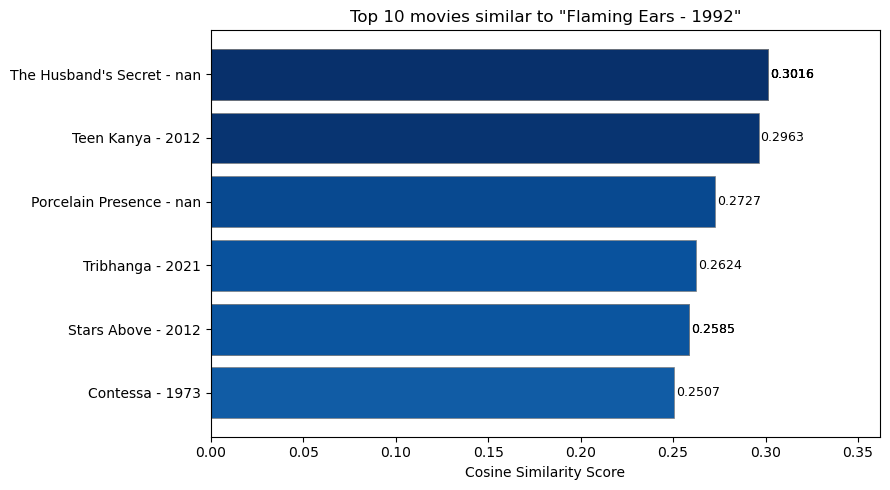

In [24]:
# see similarity scores visually

import matplotlib.pyplot as plt

# Get recommendations for the first real title
test_title = train_df['title'].dropna().iloc[0]
recs_plot  = get_recommendations(title=test_title, top_n=10)

if recs_plot is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    
    colors = plt.cm.Blues(
        [s / recs_plot['similarity_score'].max() for s in recs_plot['similarity_score']]
    )
    bars = ax.barh(
        recs_plot['title'][::-1],
        recs_plot['similarity_score'][::-1],
        color=colors[::-1],
        edgecolor='grey',
        linewidth=0.5
    )
    
    # Add score labels on each bar
    for bar, score in zip(bars, recs_plot['similarity_score'][::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{score:.4f}', va='center', fontsize=9)
    
    ax.set_xlabel('Cosine Similarity Score')
    ax.set_title(f'Top 10 movies similar to "{test_title}"')
    ax.set_xlim(0, recs_plot['similarity_score'].max() * 1.2)
    plt.tight_layout()
    plt.show()

In [25]:
# A interactive loop  type a title or description, see results
# Type 'quit' to stop

while True:
    print("\n" + "="*50)
    user_input = input("Enter a movie title or plot description (or 'quit'): ").strip()
    
    if user_input.lower() == 'quit':
        print("Done!")
        break
    
    if not user_input:
        continue
    
    # Try as title first, fall back to description
    exact = train_df[train_df['title'].str.lower() == user_input.lower()]
    
    if not exact.empty:
        print(f"\n Found '{user_input}' as a title!\n")
        result = get_recommendations(title=user_input, top_n=5)
    else:
        print(f"\n Not found as a title  searching by description...\n")
        result = get_recommendations(description=user_input, top_n=5)
    
    if result is not None:
        display(result)
    else:
        print("No results found.")

Enter a movie title or plot description (or 'quit'):  hero



 Not found as a title  searching by description...



,title,genre,similarity_score
rank,,,
1,Alyas Sakay - 1961,Thriller,0.6073
2,Alyas Sakay - 1961,Action,0.6073
3,Babak 2020 - nan,History,0.5831
4,Brotherhood - 2014,Action,0.5722
5,Brotherhood - 2014,Family,0.5722


Enter a movie title or plot description (or 'quit'):  quit


Done!


In [26]:
# This shows you EXACTLY what the system does step by step

test_title = train_df['title'].dropna().iloc[0]
print(f"Query movie: '{test_title}'")
print("="*55)

# Step 1: Get the raw description
raw_desc = train_df[train_df['title'] == test_title]['description'].values[0]
print(f"\n📄 Step 1 — Raw description:")
print(f"   {raw_desc[:200]}...")

# Step 2: After cleaning
clean = train_df[train_df['title'] == test_title]['clean_desc'].values[0]
print(f"\n🧹 Step 2 — After cleaning:")
print(f"   {clean[:200]}...")

# Step 3: TF-IDF vector (top terms)
query_vec     = tfidf.transform([clean])
feature_names = tfidf.get_feature_names_out()
scores        = query_vec.toarray().flatten()
top_idx       = scores.argsort()[::-1][:8]
print(f"\n Step 3 — Top TF-IDF terms (most important words):")
for i in top_idx:
    bar = '|' * int(scores[i] * 80)
    print(f"   {feature_names[i]:20s} {scores[i]:.4f}  {bar}")

# Step 4: Similarity scores
sim_scores  = cosine_similarity(query_vec, tfidf_matrix).flatten()
self_mask   = train_df['title'] == test_title
sim_scores[self_mask.values] = 0
top5_idx    = sim_scores.argsort()[::-1][:5]
print(f"\n Step 4 — Top 5 cosine similarity scores:")
for idx in top5_idx:
    t = train_df.iloc[idx]['title']
    s = sim_scores[idx]
    bar = '█' * int(s * 200)
    print(f"   {t:35s} {s:.4f}  {bar}")

Query movie: 'Flaming Ears - 1992'

📄 Step 1 — Raw description:
   Flaming Ears is a pop sci-fi lesbian fantasy feature set in the year 2700 in the fictive burned-out city of Asche. It follows the tangled lives of three women - Volley, Nun and Spy....

🧹 Step 2 — After cleaning:
   flame ear pop scifi lesbian fantasi featur set year fictiv burnedout citi asch follow tangl live three women volley nun spi...

 Step 3 — Top TF-IDF terms (most important words):
   set year             0.2989  |||||||||||||||||||||||
   ear                  0.2973  |||||||||||||||||||||||
   live three           0.2832  ||||||||||||||||||||||
   three women          0.2714  |||||||||||||||||||||
   lesbian              0.2641  |||||||||||||||||||||
   flame                0.2630  |||||||||||||||||||||
   tangl                0.2608  ||||||||||||||||||||
   nun                  0.2578  ||||||||||||||||||||

 Step 4 — Top 5 cosine similarity scores:
   The Husband's Secret - nan          0.3016  █████████████